## X-Ray Binary Classifier: Organic vs Inorganic
### UROP Project | SRM IST | 2025-26
**Team:** Madhankumar (RA2311003010231) & Vedant Vadke (RA2311026010791)

---
> **Scope:** Organic vs Inorganic classification only. Explosives folder is completely ignored.

## Step 0: GPU Check & Drive Mount

In [1]:
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT AVAILABLE — switch to GPU runtime')

from google.colab import drive
drive.mount('/content/drive')

GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 1: Verify Dataset

In [7]:
import os

DATASET = '/content/drive/MyDrive/xray_clean'

for cls in ['organic', 'inorganic']:
    path  = os.path.join(DATASET, cls)
    files = os.listdir(path) if os.path.exists(path) else []
    exts  = set(os.path.splitext(f)[1].lower() for f in files)
    print(f'✅ {cls:12s} — {len(files):4d} files | extensions: {exts}')

# Explosives: just confirm we're ignoring it
exp_path = os.path.join(DATASET, 'explosives')
print(f'⏭️  explosives   — IGNORED ({len(os.listdir(exp_path)) if os.path.exists(exp_path) else 0} files skipped)')

✅ organic      —  451 files | extensions: {'.jpg'}
✅ inorganic    —  451 files | extensions: {'.jpg'}
⏭️  explosives   — IGNORED (0 files skipped)


## Step 2: Install & Setup

In [8]:
!pip install -q torch torchvision scikit-learn matplotlib opencv-python tqdm

!mkdir -p /content/xray_binary/{data,models,outputs}
%cd /content/xray_binary

# Copy scripts from Drive
import shutil, os
SCRIPTS = '/content/drive/MyDrive/xray_binary'
for src, dst in [
    ('data/prepare_dataset.py',    'data/prepare_dataset.py'),
    ('models/train_classifier.py', 'models/train_classifier.py'),
    ('models/evaluate.py',         'models/evaluate.py'),
]:
    full = os.path.join(SCRIPTS, src)
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    if os.path.exists(full):
        shutil.copy(full, dst)
        print(f'✅ {src}')
    else:
        print(f'❌ {src} — upload xray_binary/ folder to Drive first')

/content/xray_binary
✅ data/prepare_dataset.py
✅ models/train_classifier.py
✅ models/evaluate.py


## Step 3: Prepare Dataset

In [13]:
!python data/prepare_dataset.py \
    --drive_path /content/drive/MyDrive/xray_clean \
    --out_dir    ./processed \
    --img_size   224 \
    --val_ratio  0.2


  X-Ray Dataset Prep  |  Organic vs Inorganic
  (Explosives: IGNORED)

[organic]
  organic: 100% 451/451 [00:11<00:00, 38.22img/s]
  train: 361  |  val: 90

[inorganic]
  inorganic: 100% 451/451 [00:09<00:00, 46.09img/s]
  train: 361  |  val: 90
  Saved classes.txt → ./processed/classes.txt

  DONE
  organic       train=361  val=90
  inorganic     train=361  val=90

  Output: ./processed/



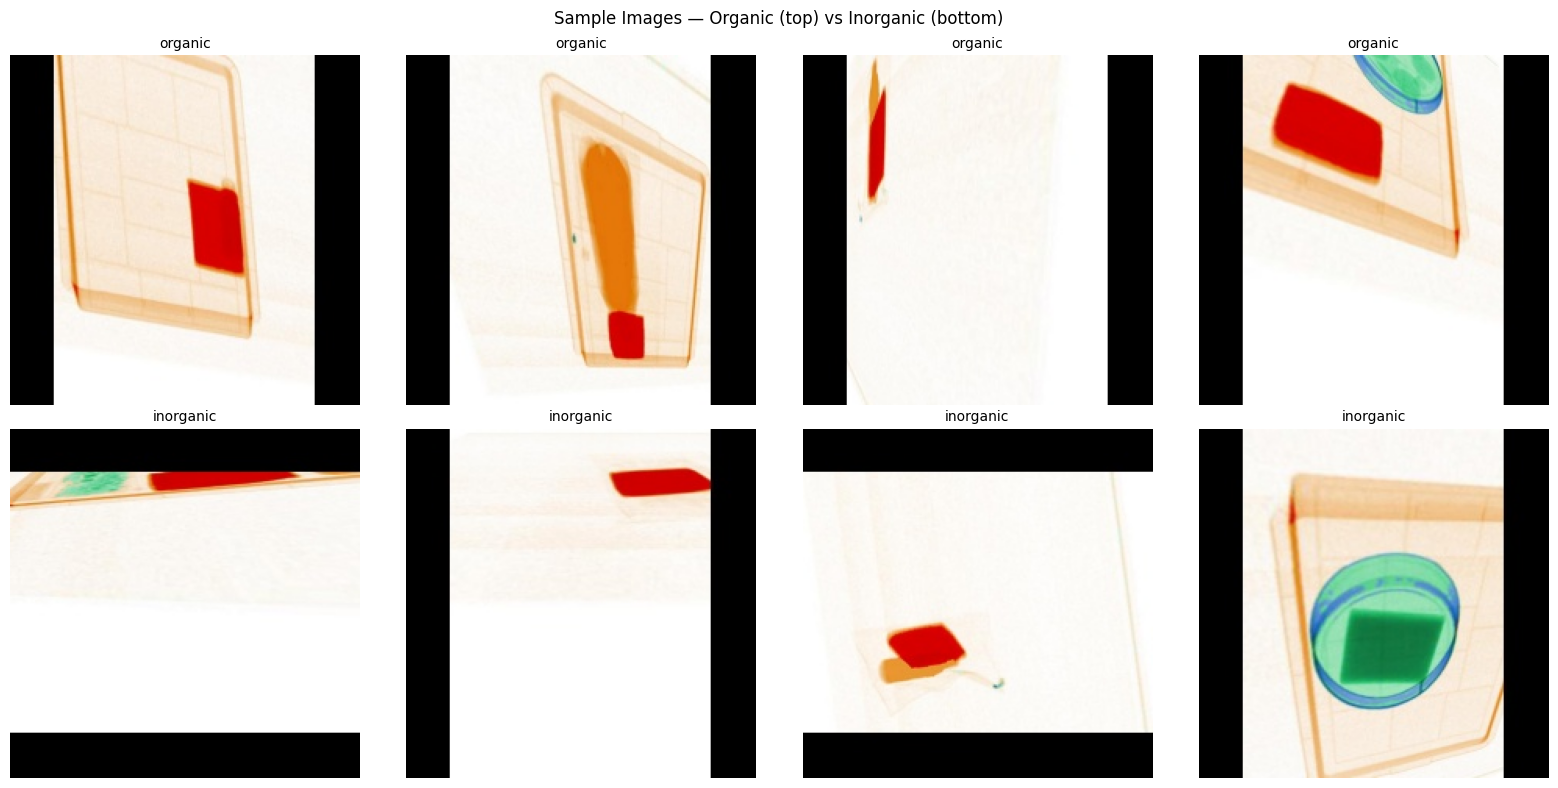

In [14]:
# Quick sanity check: visualise a few samples
import matplotlib.pyplot as plt, cv2, os, random, glob

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, cls in enumerate(['organic', 'inorganic']):
    files = glob.glob(f'./processed/train/{cls}/*.jpg')
    sample = random.sample(files, min(4, len(files)))
    for col, f in enumerate(sample):
        img = cv2.imread(f)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(cls, fontsize=10)
        axes[row][col].axis('off')
plt.suptitle('Sample Images — Organic (top) vs Inorganic (bottom)')
plt.tight_layout()
plt.show()

## Step 4: Train Classifier
*EfficientNet-B0 fine-tuned. Expected ~15–25 min on T4 GPU for 30 epochs.*

In [20]:
!python models/train_classifier.py \
    --data_dir  ./processed \
    --out_dir   ./outputs/classifier \
    --epochs    35 \
    --batch     32 \
    --img_size  224 \
    --lr        0.001


Device: cuda
  Classes: ['inorganic', 'organic']
  Train: 722  |  Val: 180

Training for 35 epochs...

Epoch 001/35  tr_loss=0.7146  tr_acc=0.5111  vl_loss=0.7151  vl_acc=0.4333  [inorganic=0.522  organic=0.344]  4.1s
  ✅ New best val_acc=0.4333 — saved
Epoch 002/35  tr_loss=0.7146  tr_acc=0.4820  vl_loss=0.7268  vl_acc=0.4333  [inorganic=0.544  organic=0.322]  5.5s
Epoch 003/35  tr_loss=0.7027  tr_acc=0.5139  vl_loss=0.7302  vl_acc=0.4278  [inorganic=0.467  organic=0.389]  4.0s
Epoch 004/35  tr_loss=0.7113  tr_acc=0.5152  vl_loss=0.7238  vl_acc=0.4444  [inorganic=0.289  organic=0.600]  3.6s
  ✅ New best val_acc=0.4444 — saved
  [Epoch 5] Unfreezing backbone...
Epoch 005/35  tr_loss=0.7111  tr_acc=0.4889  vl_loss=0.7474  vl_acc=0.4389  [inorganic=0.778  organic=0.100]  5.6s
Epoch 006/35  tr_loss=0.6963  tr_acc=0.5194  vl_loss=0.7611  vl_acc=0.3889  [inorganic=0.611  organic=0.167]  5.2s
Epoch 007/35  tr_loss=0.7069  tr_acc=0.5055  vl_loss=0.7583  vl_acc=0.3556  [inorganic=0.644  organ

## Step 5: Evaluate

In [21]:
!python models/evaluate.py \
    --model    ./outputs/classifier/best_model.pt \
    --data_dir ./processed \
    --out_dir  ./outputs/eval \
    --img_size 224

Loaded model from ./outputs/classifier/best_model.pt
Evaluating: 100% 6/6 [00:01<00:00,  5.53it/s]

  Classification Report
              precision    recall  f1-score   support

     organic       0.42      0.29      0.34        90
   inorganic       0.46      0.60      0.52        90

    accuracy                           0.44       180
   macro avg       0.44      0.44      0.43       180
weighted avg       0.44      0.44      0.43       180

Overall Accuracy: 0.4444
  Saved confusion matrix → ./outputs/eval/confusion_matrix.png
  Saved ROC curve → ./outputs/eval/roc_curve.png
  Saved training history → ./outputs/eval/training_history.png
  Saved sample predictions → ./outputs/eval/sample_predictions.png

All evaluation outputs saved → ./outputs/eval/


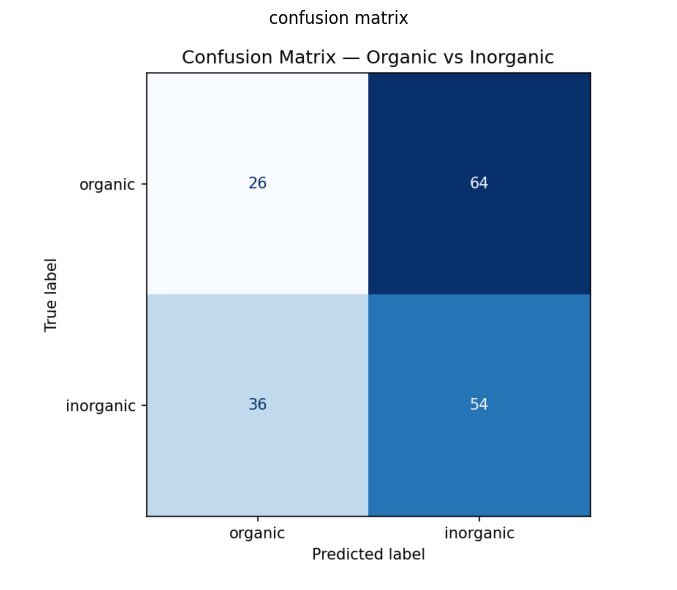

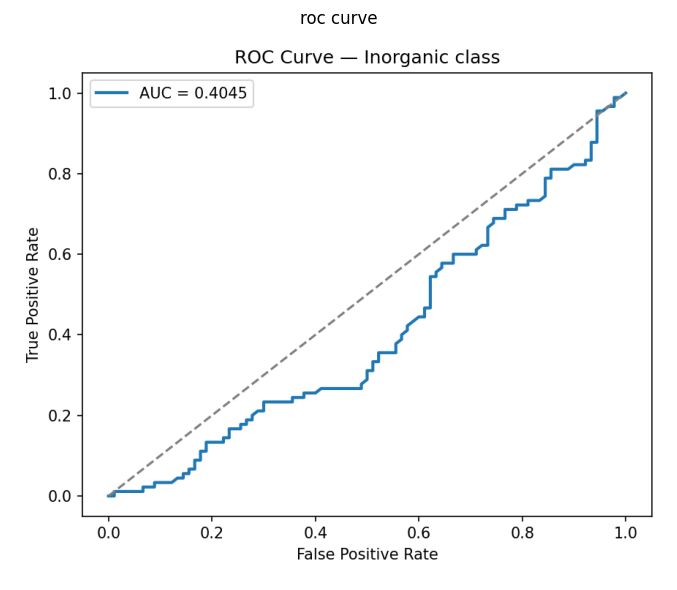

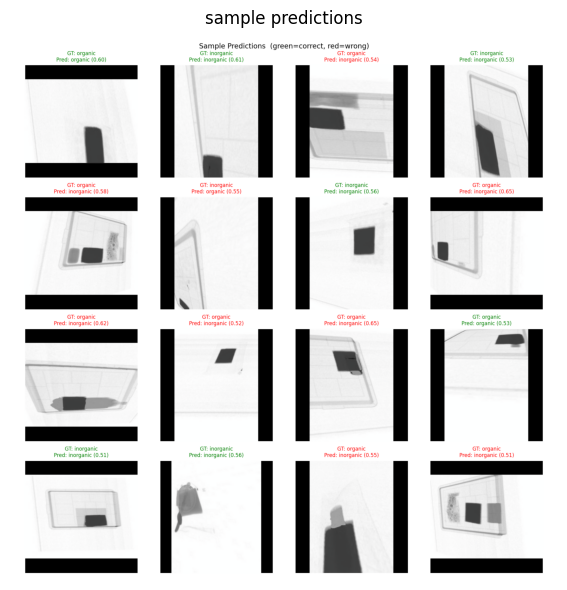

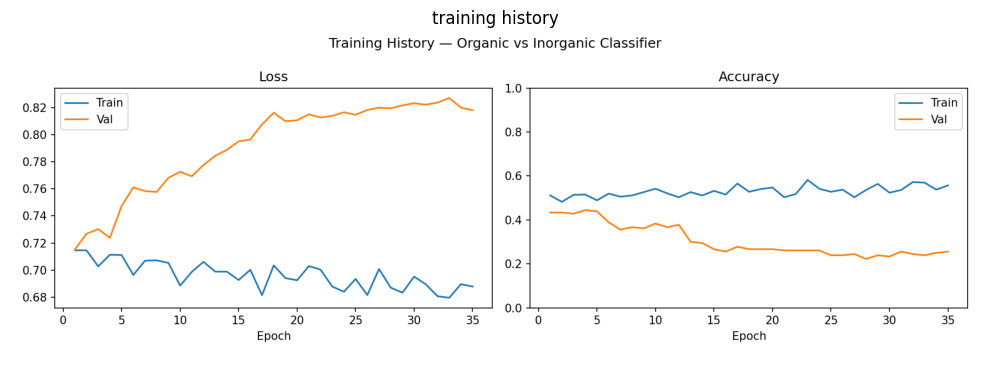

In [22]:
# Display all result plots inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

plots = glob.glob('./outputs/eval/*.png')
for p in sorted(plots):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(mpimg.imread(p))
    ax.axis('off')
    ax.set_title(p.split('/')[-1].replace('_', ' ').replace('.png', ''), fontsize=12)
    plt.tight_layout()
    plt.show()

## Step 6: Quick Inference on a Single Image

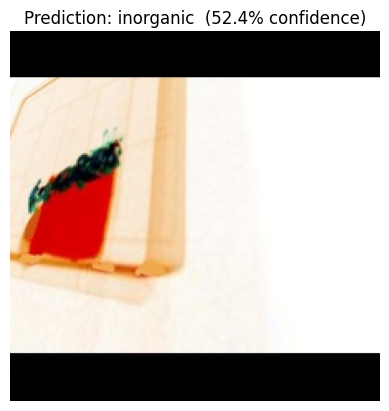

Predicted: inorganic | Confidence: 0.5237


In [23]:
import torch, torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

CLASS_NAMES = ['organic', 'inorganic']

def load_model(path):
    m = models.efficientnet_b0(weights=None)
    m.classifier = nn.Sequential(nn.Dropout(0.3, True), nn.Linear(1280, 2))
    m.load_state_dict(torch.load(path, map_location='cpu'))
    m.eval()
    return m

def predict(model, img_path):
    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    img = Image.open(img_path)
    t   = tf(img).unsqueeze(0)
    with torch.no_grad():
        out   = model(t)
        probs = torch.softmax(out, dim=1)[0]
        pred  = probs.argmax().item()
    return CLASS_NAMES[pred], probs[pred].item(), img

model = load_model('./outputs/classifier/best_model.pt')

# ← Change this to any image path
TEST_IMAGE = './processed/val/organic/organic_00000.jpg'

label, conf, img = predict(model, TEST_IMAGE)
plt.imshow(img, cmap='gray')
plt.title(f'Prediction: {label}  ({conf*100:.1f}% confidence)')
plt.axis('off')
plt.show()
print(f'Predicted: {label} | Confidence: {conf:.4f}')

## Step 7: Save Everything to Drive

In [19]:
import shutil
SAVE = '/content/drive/MyDrive/xray_binary_outputs'
shutil.copytree('./outputs', SAVE, dirs_exist_ok=True)
print(f'Saved → {SAVE}')

Saved → /content/drive/MyDrive/xray_binary_outputs
